# Delta-Hedged Free Call Option — Strategy Backtest

**Setup:** Receive free 4Y American call, modeled as 1Y / IV=60% for hedging. Strike 10% OTM at issuance. Delta hedge with short perps (daily rebalance). Reset on 20% ITM: exercise, capture intrinsic, get new 10% OTM call.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

SIGMA        = 0.60
T_MODEL      = 1.0
STRIKE_OTM   = 0.10
RESET_ITM    = 0.20
FUNDING_RATE = 0.10
NOTIONAL     = 1.0

In [2]:
def bs_delta(S, K, T, sigma, r=0.0):
    if T <= 0:
        return 1.0 if S >= K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def bs_price(S, K, T, sigma, r=0.0):
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def fetch_eth_prices(start, end):
    import yfinance as yf
    df = yf.download('ETH-USD', start=start, end=end, auto_adjust=True, progress=False)
    series = df['Close'].squeeze()
    series.index = pd.to_datetime(series.index).normalize()
    series.index.name = 'date'
    return series.sort_index()

def run_backtest(prices, t_model=T_MODEL, sigma=SIGMA):
    dates  = prices.index
    spots  = prices.values
    n      = len(spots)
    strike       = spots[0] * (1 + STRIKE_OTM)
    perp_pos     = -bs_delta(spots[0], strike, t_model, sigma) * NOTIONAL
    cash_pnl     = 0.0
    funding_paid = 0.0
    resets       = []
    daily        = []
    for i in range(1, n):
        S_prev = spots[i - 1]
        S      = spots[i]
        fund_cost     = FUNDING_RATE * abs(perp_pos) * S / 365
        cash_pnl     -= fund_cost
        funding_paid += fund_cost
        new_delta  = bs_delta(S, strike, t_model, sigma)
        cash_pnl  += perp_pos * (S - S_prev)
        perp_pos   = -new_delta * NOTIONAL
        if S / strike - 1 >= RESET_ITM:
            intrinsic  = (S - strike) * NOTIONAL
            cash_pnl  += intrinsic
            old_strike = strike
            strike     = S * (1 + STRIKE_OTM)
            perp_pos   = -bs_delta(S, strike, t_model, sigma) * NOTIONAL
            resets.append({'date': dates[i], 'spot': S,
                           'old_strike': old_strike, 'new_strike': strike,
                           'intrinsic': intrinsic})
        opt_val = bs_price(S, strike, t_model, sigma)
        daily.append({'date': dates[i], 'spot': S, 'strike': strike,
                      'delta': bs_delta(S, strike, t_model, sigma),
                      'opt_value': opt_val, 'cash_pnl': cash_pnl,
                      'total_pnl': cash_pnl + opt_val * NOTIONAL,
                      'funding_paid': funding_paid})
    return pd.DataFrame(daily).set_index('date'), pd.DataFrame(resets)

## Test 1: Bull Run — Jan–Jul 2021
ETH: $730 → $2,275 (+211%) | Model: 0.25Y / 40% IV / 20% ITM reset

In [ ]:
prices_bull = fetch_eth_prices('2021-01-01', '2021-07-01')
results_bull, resets_bull = run_backtest(prices_bull, t_model=0.25, sigma=0.40)

start_spot = prices_bull.iloc[0]
f = results_bull.iloc[-1]
intrinsic_total = resets_bull['intrinsic'].sum() if len(resets_bull) else 0
perp_pnl = f['cash_pnl'] - intrinsic_total

print(f'ETH: ${prices_bull.iloc[0]:,.0f} to ${prices_bull.iloc[-1]:,.0f}  ({(prices_bull.iloc[-1]/prices_bull.iloc[0]-1)*100:+.1f}%)')
print(f'Model: 0.25Y tenor, 40% IV')
print(f'Cash P&L:     ${f["cash_pnl"]:+,.2f}  ({f["cash_pnl"]/start_spot*100:+.1f}%)')
print(f'  Perp P&L:   ${perp_pnl:+,.2f}')
print(f'  Intrinsic:  ${intrinsic_total:+,.2f}')
print(f'  Funding:   -${f["funding_paid"]:,.2f}')
print(f'Resets: {len(resets_bull)}')
if len(resets_bull):
    for _, r in resets_bull.iterrows():
        print(f'  {r["date"].date()}  spot=${r["spot"]:,.0f}  K: ${r["old_strike"]:,.0f}->\${r["new_strike"]:,.0f}  intrinsic=${r["intrinsic"]:,.2f}')

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Delta-Hedged Free Call — Bull Run (Jan-Jul 2021) | 0.25Y / 40% IV', fontsize=13)
ax1, ax2, ax3 = axes
ax1.plot(results_bull.index, results_bull['spot'], color='steelblue', label='ETH spot')
ax1.plot(results_bull.index, results_bull['strike'], color='orange', linestyle='--', label='Strike')
for _, r in resets_bull.iterrows():
    ax1.axvline(r['date'], color='green', alpha=0.4, linewidth=1.5)
ax1.set_ylabel('Price (USD)'); ax1.legend(fontsize=8); ax1.set_title('ETH Price & Strike (green = upside reset)')
ax2.plot(results_bull.index, results_bull['cash_pnl'], color='darkgreen', label='Cash P&L (realised)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('USD'); ax2.legend(fontsize=8); ax2.set_title('Cumulative Cash P&L')
ax3.plot(results_bull.index, results_bull['delta'], color='coral', label='Delta')
ax3.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
ax3.set_ylabel('Delta'); ax3.legend(fontsize=8); ax3.set_title('Hedge Delta')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.tight_layout(); plt.savefig('backtest_bull.png', dpi=150); plt.show()

## Test 2: Bear Crash — Nov 2021–Jun 2022
ETH: $4,325 → $1,099 (-75%) | Model: 4Y / 80% IV / 20% ITM reset

In [ ]:
prices_bear = fetch_eth_prices('2021-11-01', '2022-06-30')
results_bear, resets_bear = run_backtest(prices_bear, t_model=4.0, sigma=0.80)

start_spot = prices_bear.iloc[0]
f = results_bear.iloc[-1]
intrinsic_total = resets_bear['intrinsic'].sum() if len(resets_bear) else 0
perp_pnl = f['cash_pnl'] - intrinsic_total

print(f'ETH: ${prices_bear.iloc[0]:,.0f} to ${prices_bear.iloc[-1]:,.0f}  ({(prices_bear.iloc[-1]/prices_bear.iloc[0]-1)*100:+.1f}%)')
print(f'Model: 4Y tenor, 80% IV')
print(f'Cash P&L:     ${f["cash_pnl"]:+,.2f}  ({f["cash_pnl"]/start_spot*100:+.1f}%)')
print(f'  Perp P&L:   ${perp_pnl:+,.2f}')
print(f'  Intrinsic:  ${intrinsic_total:+,.2f}')
print(f'  Funding:   -${f["funding_paid"]:,.2f}')
print(f'Resets: {len(resets_bear)}')

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Delta-Hedged Free Call — Bear Crash (Nov 2021-Jun 2022) | 4Y / 80% IV', fontsize=13)
ax1, ax2, ax3 = axes
ax1.plot(results_bear.index, results_bear['spot'], color='steelblue', label='ETH spot')
ax1.plot(results_bear.index, results_bear['strike'], color='orange', linestyle='--', label='Strike')
ax1.set_ylabel('Price (USD)'); ax1.legend(fontsize=8); ax1.set_title('ETH Price & Strike')
ax2.plot(results_bear.index, results_bear['cash_pnl'], color='darkgreen', label='Cash P&L (realised)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('USD'); ax2.legend(fontsize=8); ax2.set_title('Cumulative Cash P&L')
ax3.plot(results_bear.index, results_bear['delta'], color='coral', label='Delta')
ax3.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
ax3.set_ylabel('Delta'); ax3.legend(fontsize=8); ax3.set_title('Hedge Delta')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.tight_layout(); plt.savefig('backtest_bear.png', dpi=150); plt.show()

## Test 3: Sideways Bear — Oct 2022–Oct 2023
ETH already low, stays low | Model: 1Y / 60% IV / 20% ITM reset

In [ ]:
prices_sideways = fetch_eth_prices('2022-10-01', '2023-10-01')
results_sideways, resets_sideways = run_backtest(prices_sideways, t_model=1.0, sigma=0.60)

start_spot = prices_sideways.iloc[0]
f = results_sideways.iloc[-1]
intrinsic_total = resets_sideways['intrinsic'].sum() if len(resets_sideways) else 0
perp_pnl = f['cash_pnl'] - intrinsic_total

print(f'ETH: ${prices_sideways.iloc[0]:,.0f} to ${prices_sideways.iloc[-1]:,.0f}  ({(prices_sideways.iloc[-1]/prices_sideways.iloc[0]-1)*100:+.1f}%)')
print(f'Model: 1Y tenor, 60% IV')
print(f'Cash P&L:     ${f["cash_pnl"]:+,.2f}  ({f["cash_pnl"]/start_spot*100:+.1f}%)')
print(f'  Perp P&L:   ${perp_pnl:+,.2f}')
print(f'  Intrinsic:  ${intrinsic_total:+,.2f}')
print(f'  Funding:   -${f["funding_paid"]:,.2f}')
print(f'Resets: {len(resets_sideways)}')
if len(resets_sideways):
    for _, r in resets_sideways.iterrows():
        print(f'  {r["date"].date()}  spot=${r["spot"]:,.0f}  K: ${r["old_strike"]:,.0f}->\${r["new_strike"]:,.0f}  intrinsic=${r["intrinsic"]:,.2f}')

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Delta-Hedged Free Call — Sideways Bear (Oct 2022–Oct 2023) | 1Y / 60% IV', fontsize=13)
ax1, ax2, ax3 = axes
ax1.plot(results_sideways.index, results_sideways['spot'], color='steelblue', label='ETH spot')
ax1.plot(results_sideways.index, results_sideways['strike'], color='orange', linestyle='--', label='Strike')
for _, r in resets_sideways.iterrows():
    ax1.axvline(r['date'], color='green', alpha=0.4, linewidth=1.5)
ax1.set_ylabel('Price (USD)'); ax1.legend(fontsize=8); ax1.set_title('ETH Price & Strike (green = upside reset)')
ax2.plot(results_sideways.index, results_sideways['cash_pnl'], color='darkgreen', label='Cash P&L (realised)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('USD'); ax2.legend(fontsize=8); ax2.set_title('Cumulative Cash P&L')
ax3.plot(results_sideways.index, results_sideways['delta'], color='coral', label='Delta')
ax3.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
ax3.set_ylabel('Delta'); ax3.legend(fontsize=8); ax3.set_title('Hedge Delta')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.tight_layout(); plt.savefig('backtest_sideways.png', dpi=150); plt.show()

### Sideways Bear — Monte Carlo Variance
500 GBM paths, S0=$1,300, 1Y horizon, σ_sim=65% (ETH realised vol Oct22–Oct23), σ_hedge=60%, funding=10%.

In [ ]:
np.random.seed(42)
N_PATHS   = 500
N_DAYS    = 365
S0        = 1300.0
MU        = 0.27        # ETH drifted ~+27% annualised over the period
SIGMA_SIM = 0.65        # ETH realised vol Oct22–Oct23

dt = 1 / 365
pnl_results = []

for _ in range(N_PATHS):
    shocks = np.random.normal((MU - 0.5 * SIGMA_SIM**2) * dt,
                               SIGMA_SIM * np.sqrt(dt), N_DAYS)
    prices_path = pd.Series(
        S0 * np.exp(np.concatenate([[0], np.cumsum(shocks)])),
        index=pd.date_range('2022-10-01', periods=N_DAYS + 1, freq='D')
    )
    prices_path.index.name = 'date'
    res, _ = run_backtest(prices_path, t_model=1.0, sigma=0.60)
    pnl_results.append(res.iloc[-1]['cash_pnl'])

pnl_arr = np.array(pnl_results)

print(f'Sideways Bear Monte Carlo — {N_PATHS} paths, σ_sim={SIGMA_SIM*100:.0f}%, μ={MU*100:.0f}%/yr')
print(f'{"─"*45}')
print(f'Mean P&L:        ${np.mean(pnl_arr):>+8,.0f}  ({np.mean(pnl_arr)/S0*100:+.1f}%)')
print(f'Median P&L:      ${np.median(pnl_arr):>+8,.0f}  ({np.median(pnl_arr)/S0*100:+.1f}%)')
print(f'Std dev:         ${np.std(pnl_arr):>8,.0f}')
print(f'Variance:        ${np.var(pnl_arr):>8,.0f}²')
print(f'5th percentile:  ${np.percentile(pnl_arr, 5):>+8,.0f}')
print(f'25th percentile: ${np.percentile(pnl_arr, 25):>+8,.0f}')
print(f'75th percentile: ${np.percentile(pnl_arr, 75):>+8,.0f}')
print(f'95th percentile: ${np.percentile(pnl_arr, 95):>+8,.0f}')
print(f'Min:             ${np.min(pnl_arr):>+8,.0f}')
print(f'Max:             ${np.max(pnl_arr):>+8,.0f}')
print(f'% profitable:    {(pnl_arr > 0).mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pnl_arr, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(pnl_arr), color='darkgreen', linewidth=1.5, label=f'Mean ${np.mean(pnl_arr):+,.0f}')
ax.axvline(np.percentile(pnl_arr, 5), color='red', linewidth=1, linestyle='--', label=f'5th pct ${np.percentile(pnl_arr,5):+,.0f}')
ax.axvline(np.percentile(pnl_arr, 95), color='orange', linewidth=1, linestyle='--', label=f'95th pct ${np.percentile(pnl_arr,95):+,.0f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cash P&L (USD)'); ax.set_ylabel('Paths')
ax.set_title(f'Sideways Bear P&L Distribution — {N_PATHS} GBM paths | 1Y/60%IV')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('mc_sideways_variance.png', dpi=150); plt.show()

## Test 3: Tenor Sweep — 0.25Y to 4Y
**Cash P&L only** (option mark excluded — unrealised and misleading for comparison).

In [7]:
tenors  = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
periods = {'Bull (Jan-Jul 2021)': prices_bull, 'Bear (Nov 2021-Jun 2022)': prices_bear}

for label, prices in periods.items():
    start_spot = prices.iloc[0]
    eth_ret = (prices.iloc[-1] / start_spot - 1) * 100
    print(f'\n{"="*70}')
    print(f'  {label}  |  ETH {eth_ret:+.1f}%')
    print(f'{"="*70}')
    print(f'  {"Tenor":>6}  {"CashPnL":>10}  {"Cash%":>7}  {"PerpPnL":>10}  {"Intrinsic":>10}  {"Funding":>8}')
    print(f'  {"-"*6}  {"-"*10}  {"-"*7}  {"-"*10}  {"-"*10}  {"-"*8}')
    for t in tenors:
        res, resets = run_backtest(prices, t_model=t)
        cash_pnl  = res.iloc[-1]['cash_pnl']
        fund_paid = res.iloc[-1]['funding_paid']
        intrinsic = resets['intrinsic'].sum() if len(resets) else 0
        perp_pnl  = cash_pnl - intrinsic
        cash_pct  = cash_pnl / start_spot * 100
        print(f'  {t:.2f}Y  ${cash_pnl:>+9,.0f}  {cash_pct:>+6.1f}%  ${perp_pnl:>+9,.0f}  ${intrinsic:>+9,.0f}  ${fund_paid:>7,.0f}')


  Bull (Jan-Jul 2021)  |  ETH +211.4%
   Tenor     CashPnL    Cash%     PerpPnL   Intrinsic   Funding
  ------  ----------  -------  ----------  ----------  --------
  0.25Y  $   +1,320  +180.7%  $     -645  $   +1,965  $     39
  0.50Y  $   +1,273  +174.2%  $     -692  $   +1,965  $     45
  0.75Y  $   +1,221  +167.2%  $     -744  $   +1,965  $     50
  1.00Y  $   +1,175  +160.9%  $     -789  $   +1,965  $     53
  1.50Y  $   +1,101  +150.8%  $     -863  $   +1,965  $     57
  2.00Y  $   +1,043  +142.8%  $     -922  $   +1,965  $     61
  3.00Y  $     +954  +130.7%  $   -1,010  $   +1,965  $     66
  4.00Y  $     +888  +121.5%  $   -1,077  $   +1,965  $     69

  Bear (Nov 2021-Jun 2022)  |  ETH -74.6%
   Tenor     CashPnL    Cash%     PerpPnL   Intrinsic   Funding
  ------  ----------  -------  ----------  ----------  --------
  0.25Y  $     +668   +15.4%  $     +668  $       +0  $     39
  0.50Y  $     +860   +19.9%  $     +860  $       +0  $     54
  0.75Y  $     +996   +23.0%  $ 

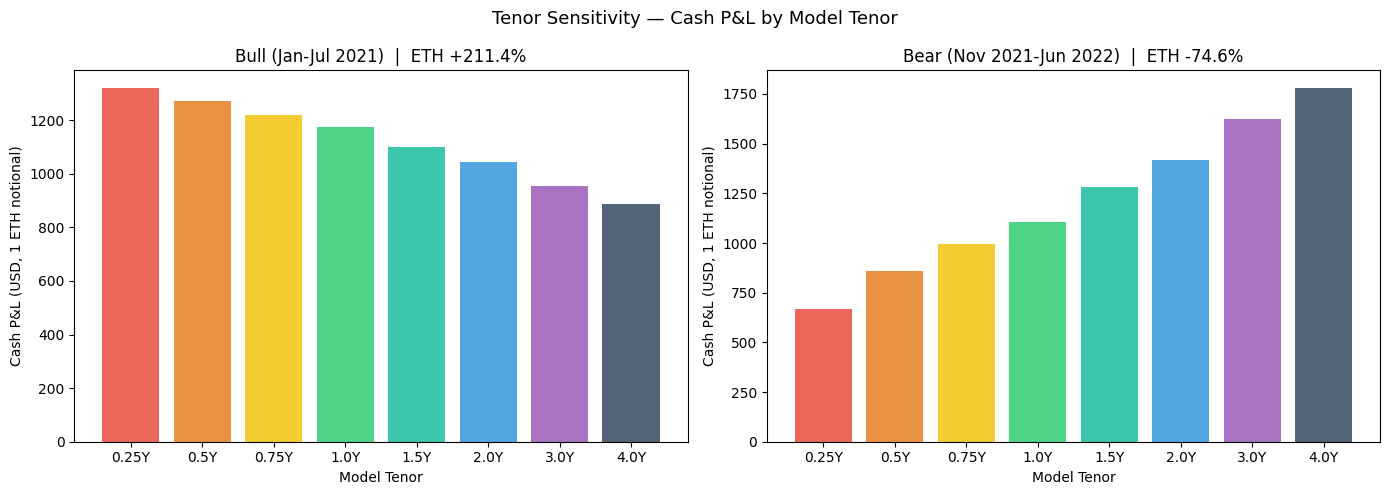

In [8]:
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6','#34495e']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tenor Sensitivity — Cash P&L by Model Tenor', fontsize=13)

for ax, (label, prices) in zip(axes, periods.items()):
    start_spot = prices.iloc[0]
    eth_ret = (prices.iloc[-1] / start_spot - 1) * 100
    cash_pnls = [run_backtest(prices, t_model=t)[0].iloc[-1]['cash_pnl'] for t in tenors]
    x = range(len(tenors))
    ax.bar(x, cash_pnls, color=colors, alpha=0.85)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f'{t}Y' for t in tenors])
    ax.set_xlabel('Model Tenor')
    ax.set_ylabel('Cash P&L (USD, 1 ETH notional)')
    ax.set_title(f'{label}  |  ETH {eth_ret:+.1f}%')

plt.tight_layout(); plt.savefig('tenor_sweep_cash.png', dpi=150); plt.show()

## Test 4: IV Sweep — 40% to 80%
**Cash P&L only.** ETH realised vol typically ranges 40%–80%.

In [9]:
import numpy as np
sigmas = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for label, prices in periods.items():
    start_spot = prices.iloc[0]
    eth_ret = (prices.iloc[-1] / start_spot - 1) * 100
    print(f'\n{"="*70}')
    print(f'  {label}  |  ETH {eth_ret:+.1f}%')
    print(f'{"="*70}')
    print(f'  {"IV":>5}  {"CashPnL":>10}  {"Cash%":>7}  {"PerpPnL":>10}  {"Intrinsic":>10}  {"Funding":>8}')
    print(f'  {"-"*5}  {"-"*10}  {"-"*7}  {"-"*10}  {"-"*10}  {"-"*8}')
    for s in sigmas:
        res, resets = run_backtest(prices, sigma=s)
        cash_pnl  = res.iloc[-1]['cash_pnl']
        fund_paid = res.iloc[-1]['funding_paid']
        intrinsic = resets['intrinsic'].sum() if len(resets) else 0
        perp_pnl  = cash_pnl - intrinsic
        cash_pct  = cash_pnl / start_spot * 100
        print(f'  {s*100:.0f}%   ${cash_pnl:>+9,.0f}  {cash_pct:>+6.1f}%  ${perp_pnl:>+9,.0f}  ${intrinsic:>+9,.0f}  ${fund_paid:>7,.0f}')


  Bull (Jan-Jul 2021)  |  ETH +211.4%
     IV     CashPnL    Cash%     PerpPnL   Intrinsic   Funding
  -----  ----------  -------  ----------  ----------  --------
  40%   $   +1,285  +175.9%  $     -680  $   +1,965  $     44
  45%   $   +1,259  +172.4%  $     -705  $   +1,965  $     47
  50%   $   +1,232  +168.7%  $     -733  $   +1,965  $     49
  55%   $   +1,204  +164.8%  $     -761  $   +1,965  $     51
  60%   $   +1,175  +160.9%  $     -789  $   +1,965  $     53
  65%   $   +1,147  +157.1%  $     -817  $   +1,965  $     54


  70%   $   +1,120  +153.3%  $     -845  $   +1,965  $     56
  75%   $   +1,093  +149.7%  $     -871  $   +1,965  $     58
  80%   $   +1,067  +146.1%  $     -897  $   +1,965  $     59

  Bear (Nov 2021-Jun 2022)  |  ETH -74.6%
     IV     CashPnL    Cash%     PerpPnL   Intrinsic   Funding
  -----  ----------  -------  ----------  ----------  --------
  40%   $     +824   +19.1%  $     +824  $       +0  $     51
  45%   $     +898   +20.8%  $     +898  $       +0  $     57
  50%   $     +969   +22.4%  $     +969  $       +0  $     63
  55%   $   +1,038   +24.0%  $   +1,038  $       +0  $     68
  60%   $   +1,106   +25.6%  $   +1,106  $       +0  $     73
  65%   $   +1,172   +27.1%  $   +1,172  $       +0  $     78
  70%   $   +1,236   +28.6%  $   +1,236  $       +0  $     83
  75%   $   +1,299   +30.0%  $   +1,299  $       +0  $     87


  80%   $   +1,360   +31.4%  $   +1,360  $       +0  $     91


## Test 5: 2D Heatmap — Tenor vs IV
Cash P&L across all combinations. Bull and bear side by side.

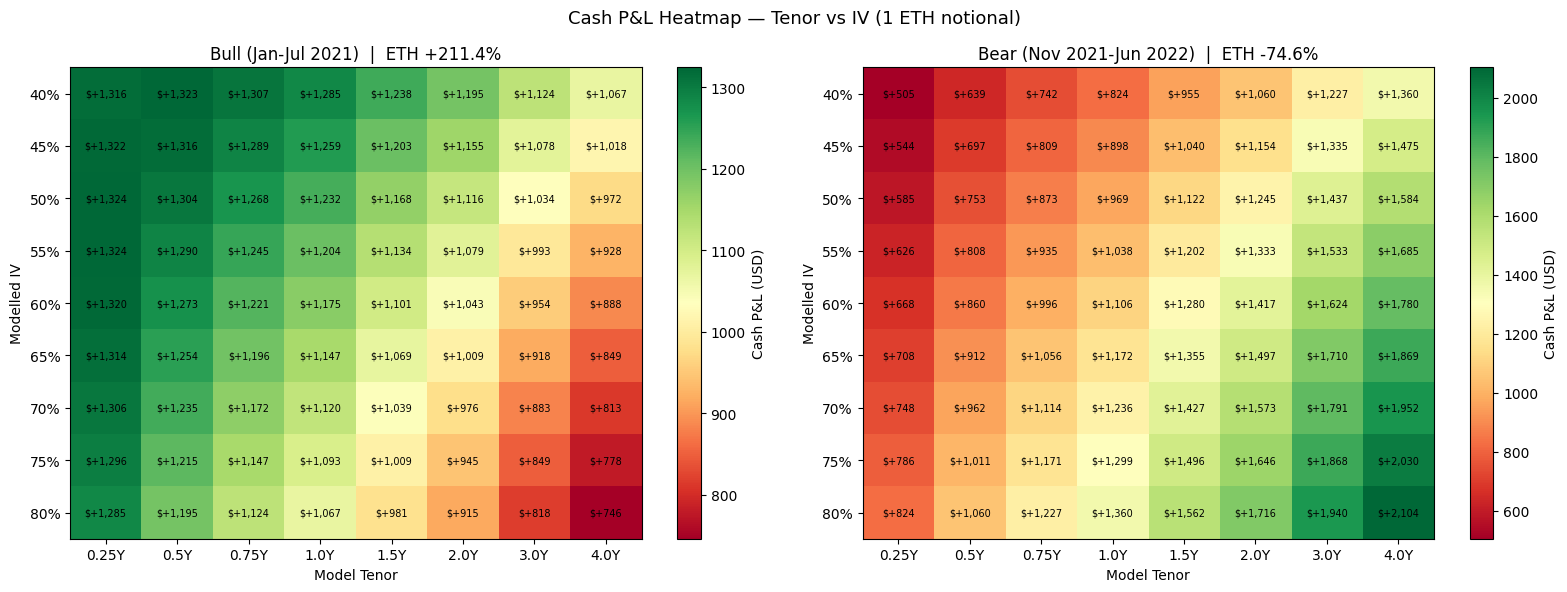

In [10]:
import matplotlib.ticker as mticker

tenors_2d = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
sigmas_2d = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cash P&L Heatmap — Tenor vs IV (1 ETH notional)', fontsize=13)

for ax, (label, prices) in zip(axes, periods.items()):
    start_spot = prices.iloc[0]
    eth_ret = (prices.iloc[-1] / start_spot - 1) * 100

    grid = np.zeros((len(sigmas_2d), len(tenors_2d)))
    for i, s in enumerate(sigmas_2d):
        for j, t in enumerate(tenors_2d):
            res, _ = run_backtest(prices, t_model=t, sigma=s)
            grid[i, j] = res.iloc[-1]['cash_pnl']

    im = ax.imshow(grid, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(tenors_2d)))
    ax.set_xticklabels([f'{t}Y' for t in tenors_2d])
    ax.set_yticks(range(len(sigmas_2d)))
    ax.set_yticklabels([f'{int(s*100)}%' for s in sigmas_2d])
    ax.set_xlabel('Model Tenor')
    ax.set_ylabel('Modelled IV')
    ax.set_title(f'{label}  |  ETH {eth_ret:+.1f}%')

    for i in range(len(sigmas_2d)):
        for j in range(len(tenors_2d)):
            ax.text(j, i, f'${grid[i,j]:+,.0f}', ha='center', va='center',
                    fontsize=7, color='black')

    plt.colorbar(im, ax=ax, label='Cash P&L (USD)')

plt.tight_layout()
plt.savefig('heatmap_tenor_iv.png', dpi=150)
plt.show()